<a href="https://colab.research.google.com/github/AKSHAYBHAMMAR/FLIGHT_RISK_PREDICTION_SYSTEM/blob/main/flight_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter Departure City: delhi
Enter Destination City: mumbai

===== ROUTE ANALYSIS =====

City: Delhi
Temp: 28.06
Wind: 1.54
Visibility: 5.0
Humidity: 47
Distance Covered: 164.6 km
Predicted Delay: 97.9

City: Sawai Madhopur
Temp: 34.97
Wind: 5.58
Visibility: 10.0
Humidity: 20
Distance Covered: 329.19 km
Predicted Delay: 96.2

City: Agar Tahsil
Temp: 35.7
Wind: 6.82
Visibility: 10.0
Humidity: 16
Distance Covered: 493.79 km
Predicted Delay: 97.72

City: Mhow Tahsil
Temp: 35.87
Wind: 6.25
Visibility: 10.0
Humidity: 12
Distance Covered: 658.38 km
Predicted Delay: 99.19

City: Shindkheda Taluka
Temp: 38.63
Wind: 5.18
Visibility: 10.0
Humidity: 11
Distance Covered: 822.98 km
Predicted Delay: 100.32

City: Nashik
Temp: 35.88
Wind: 6.73
Visibility: 10.0
Humidity: 17
Distance Covered: 987.58 km
Predicted Delay: 110.47

City: Mumbai
Temp: 38
Wind: 5.66
Visibility: 3.5
Humidity: 30
Distance Covered: 1152.17 km
Predicted Delay: 116.13

===== FINAL RESULT =====
Route: Delhi → Mumbai
Full Route: Delh

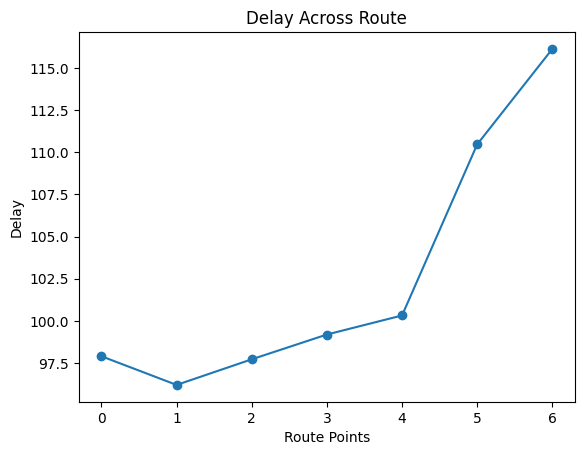

In [ ]:
# ================== IMPORTS ==================
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
from math import radians, sin, cos, sqrt, atan2

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


# ================== WEATHER API ==================
API_KEY = "1ba7a5c4137bda36dd6a1b0736778a63"


# ================== DISTANCE (REAL) ==================
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius (km)

    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c


# ================== API FUNCTIONS ==================
def get_coordinates(city):
    url = f"http://api.openweathermap.org/geo/1.0/direct?q={city}&limit=1&appid={API_KEY}"
    data = requests.get(url).json()

    if not data:
        raise ValueError(f"City not found: {city}")

    return data[0]['lat'], data[0]['lon']


def get_weather(lat, lon):
    try:
        url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={API_KEY}&units=metric"
        data = requests.get(url).json()

        temp = data['main']['temp']
        humidity = data['main']['humidity']
        wind = data['wind']['speed']
        visibility = data.get('visibility', 10000) / 1000

        return temp, wind, visibility, humidity
    except:
        # fallback values
        return 30, 10, 6, 70


def get_city_name(lat, lon):
    try:
        url = f"http://api.openweathermap.org/geo/1.0/reverse?lat={lat}&lon={lon}&limit=1&appid={API_KEY}"
        data = requests.get(url).json()

        if data:
            return data[0]['name']
    except:
        pass

    return "Unknown"


# ================== OSRM ROUTE ==================
def get_route_points_osrm(lat1, lon1, lat2, lon2):
    url = f"http://router.project-osrm.org/route/v1/driving/{lon1},{lat1};{lon2},{lat2}?overview=full&geometries=geojson"
    response = requests.get(url).json()

    coords = response['routes'][0]['geometry']['coordinates']

    step = max(1, len(coords)//6)
    return coords[::step]


# ================== BETTER DATA ==================
# Now delay is more realistic (based on logic)
data = []

for _ in range(200):
    distance = np.random.randint(100, 2000)
    temp = np.random.randint(20, 40)
    wind = np.random.randint(5, 20)
    visibility = np.random.randint(2, 10)
    humidity = np.random.randint(40, 90)

    # improved delay logic
    delay = (
        distance * 0.02 +
        (40 - visibility) * 2 +
        humidity * 0.1 +
        wind * 1.5 +
        np.random.randint(0, 10)
    )

    data.append([distance, temp, wind, visibility, humidity, delay])

df = pd.DataFrame(data, columns=[
    'distance_km', 'temperature', 'wind_speed',
    'visibility', 'humidity', 'delay_minutes'
])

feature_columns = ['temperature', 'wind_speed', 'visibility', 'humidity', 'distance_km']

X = df[feature_columns]
y = df['delay_minutes']


# ================== MODEL ==================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor(n_estimators=200)
model.fit(X_train, y_train)


# ================== PREDICTION ==================
def predict_delay(temp, wind, vis, hum, distance):

    input_df = pd.DataFrame([{
        'temperature': temp,
        'wind_speed': wind,
        'visibility': vis,
        'humidity': hum,
        'distance_km': distance
    }])

    input_df = input_df.reindex(columns=feature_columns, fill_value=0)

    return round(model.predict(input_df)[0], 2)


# ================== MAIN FUNCTION ==================
def analyze_route(departure, destination):

    lat1, lon1 = get_coordinates(departure)
    lat2, lon2 = get_coordinates(destination)

    total_distance = haversine(lat1, lon1, lat2, lon2)

    route_points = get_route_points_osrm(lat1, lon1, lat2, lon2)

    route_cities = []
    delays = []

    print("\n===== ROUTE ANALYSIS =====")

    for i, (lon, lat) in enumerate(route_points):

        temp, wind, vis, hum = get_weather(lat, lon)

        # progressive distance instead of random
        distance = (i + 1) / len(route_points) * total_distance

        delay = predict_delay(temp, wind, vis, hum, distance)

        city = get_city_name(lat, lon)

        if city not in route_cities and city != "Unknown":
            route_cities.append(city)

        delays.append(delay)

        print(f"\nCity: {city}")
        print("Temp:", temp)
        print("Wind:", wind)
        print("Visibility:", vis)
        print("Humidity:", hum)
        print("Distance Covered:", round(distance, 2), "km")
        print("Predicted Delay:", delay)

    avg_delay = sum(delays)/len(delays)

    print("\n===== FINAL RESULT =====")
    print("Route:", departure.title(), "→", destination.title())
    print("Full Route:", " → ".join(route_cities))
    print("Total Distance:", round(total_distance, 2), "km")
    print("Average Delay:", round(avg_delay, 2), "minutes")

    plt.figure()
    plt.plot(delays, marker='o')
    plt.title("Delay Across Route")
    plt.xlabel("Route Points")
    plt.ylabel("Delay")
    plt.show()


# ================== USER INPUT ==================
departure = input("Enter Departure City: ")
destination = input("Enter Destination City: ")

analyze_route(departure, destination)